In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import polars as pl

event_frames = []
counter = 0

# load pl season match ids
match_ids = pl.read_csv('premier_league_season_15_16_matches.csv').select('match_id').to_series().to_list()

for id in match_ids:
    file = Path(f'data/events/{id}.json')
    counter += 1
    event_frames.append(
        pl.read_json(file, infer_schema_length=None).with_columns(
            pl.lit(int(file.stem), dtype=pl.Int64).alias('match_id')
        )
    )

prem_events_df = pl.concat(event_frames, how='diagonal_relaxed')
base_columns = [
    'id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession',
    'possession_team', 'play_pattern', 'team', 'duration', 'tactics', 'match_id',
    'related_events', 'player', 'position', 'location',
]
prem_events_df = prem_events_df.select(base_columns + [
    column for column in prem_events_df.columns if column not in base_columns
])

matches

In [3]:
all_teams = prem_events_df.select('team').unique().to_series().to_list()
all_players = prem_events_df.select('player').unique().to_series().to_list()

In [4]:
teams_dict = {team['id']: team['name'] for team in all_teams}
players_dict = {player['id']: player['name'] for player in all_players if isinstance(player, dict)}

# write dicts to parquet
pl.DataFrame(list(teams_dict.items()), schema=['team_id', 'team_name']).write_parquet('teams.parquet')
pl.DataFrame(list(players_dict.items()), schema=['player_id', 'player_name']).write_parquet('players.parquet')

/var/folders/h_/lg0zhls57_l_8r2q6kbmsszw0000gn/T/ipykernel_57075/1250344635.py:5: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  pl.DataFrame(list(teams_dict.items()), schema=['team_id', 'team_name']).write_parquet('teams.parquet')
/var/folders/h_/lg0zhls57_l_8r2q6kbmsszw0000gn/T/ipykernel_57075/1250344635.py:6: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  pl.DataFrame(list(players_dict.items()), schema=['player_id', 'player_name']).write_parquet('players.parquet')


In [5]:
# write dicts to csv
pl.DataFrame(list(teams_dict.items()), schema=['team_id', 'team_name']).write_csv('premier_league_teams_15_16.csv')
pl.DataFrame(list(players_dict.items()), schema=['player_id', 'player_name']).write_csv('premier_league_players_15_16.csv')

/var/folders/h_/lg0zhls57_l_8r2q6kbmsszw0000gn/T/ipykernel_57075/3543639167.py:2: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  pl.DataFrame(list(teams_dict.items()), schema=['team_id', 'team_name']).write_csv('premier_league_teams_15_16.csv')
/var/folders/h_/lg0zhls57_l_8r2q6kbmsszw0000gn/T/ipykernel_57075/3543639167.py:3: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  pl.DataFrame(list(players_dict.items()), schema=['player_id', 'player_name']).write_csv('premier_league_players_15_16.csv')


In [6]:
non_playing_events_ids = [5, 18, 19, 26, 27, 29, 34, 35, 36, 40]
# rename carry to carry_to
prem_events_df = prem_events_df.rename({'carry': 'carry_to'})
def set_to_id(value):
    return int(value['id']) if isinstance(value, dict) and 'id' in value else value

id_cols = ['type', 'possession_team', 'play_pattern', 'team', 'player', 'position']
prem_events_df = prem_events_df.with_columns(
    pl.col(column).map_elements(set_to_id, return_dtype=pl.Int64).alias(column)
    for column in id_cols
)

In [7]:
cols_to_expand = prem_events_df.columns[18:]
for col in cols_to_expand:
    dtype = prem_events_df.schema[col]
    if isinstance(dtype, pl.Struct):
        prem_events_df = prem_events_df.with_columns(
            pl.col(col).struct.field(field.name).alias(f'{col}_{field.name}')
            for field in dtype.fields
        ).drop(col)

for col in prem_events_df.columns:
    dtype = prem_events_df.schema[col]
    if isinstance(dtype, pl.Struct) and 'id' in {field.name for field in dtype.fields}:
        prem_events_df = prem_events_df.with_columns(pl.col(col).struct.field('id').alias(col))


In [8]:
playing_events_df = prem_events_df.filter(~pl.col('type').is_in(non_playing_events_ids))
playing_events_df = playing_events_df.drop('tactics')
nAn = playing_events_df.get_column('block_deflection').unique().to_list()[0]
print(playing_events_df.schema)

Schema([('id', String), ('index', Int64), ('period', Int64), ('timestamp', String), ('minute', Int64), ('second', Int64), ('type', Int64), ('possession', Int64), ('possession_team', Int64), ('play_pattern', Int64), ('team', Int64), ('duration', Float64), ('match_id', Int64), ('related_events', List(String)), ('player', Int64), ('position', Int64), ('location', List(Float64)), ('under_pressure', Boolean), ('counterpress', Boolean), ('out', Boolean), ('off_camera', Boolean), ('pass_recipient', Int64), ('pass_length', Float64), ('pass_angle', Float64), ('pass_height', Int64), ('pass_end_location', List(Float64)), ('pass_body_part', Int64), ('pass_outcome', Int64), ('pass_type', Int64), ('pass_aerial_won', Boolean), ('pass_deflected', Boolean), ('pass_switch', Boolean), ('pass_through_ball', Boolean), ('pass_technique', Int64), ('pass_assisted_shot_id', String), ('pass_shot_assist', Boolean), ('pass_cross', Boolean), ('pass_cut_back', Boolean), ('pass_inswinging', Boolean), ('pass_outswing

In [9]:
from tools_file import *
# load json files 
event_types_dict = json_file_to_dict('info/event_type.json')
positions_dict = json_file_to_dict('info/position.json')
positions_abbrev_dict = json_file_to_dict('info/position.json', value_field='abbrev')
play_patterns_dict = json_file_to_dict('info/play_pattern.json')

In [10]:
event_types_dict[33] = '50-50'

In [11]:
end_loc_cols = [s for s in playing_events_df.columns if "end_location" in s]
outcome_cols = [s for s in playing_events_df.columns if "outcome" in s]
type_cols = [s for s in playing_events_df.columns if "_type" in s]
technique_cols = [s for s in playing_events_df.columns if "technique" in s]
body_part_cols = [s for s in playing_events_df.columns if "body_part" in s]
aerial_won_cols = [s for s in playing_events_df.columns if "aerial_won" in s]

playing_events_df = playing_events_df.with_columns(
    pl.coalesce(end_loc_cols).alias('end_location'),
    pl.coalesce(outcome_cols).alias('outcome'),
    pl.coalesce(type_cols).alias('action_type'),
    pl.coalesce(technique_cols).alias('technique'),
    pl.coalesce(body_part_cols).alias('body_part'),
    pl.coalesce(aerial_won_cols).alias('aerial_won'),
).drop(end_loc_cols + outcome_cols + type_cols + technique_cols + body_part_cols + aerial_won_cols)

all_null_columns = [
    column for column in playing_events_df.columns
    if playing_events_df.get_column(column).null_count() == playing_events_df.height
]
playing_events_df = playing_events_df.drop(all_null_columns)

playing_events_df = playing_events_df.with_columns(
    (pl.lit(72) - pl.col('foul_committed_card')).alias('foul_committed_card'),
    (pl.lit(72) - pl.col('bad_behaviour_card')).alias('bad_behaviour_card'),
)

# collapse body part cols
clearance_cols = [s for s in playing_events_df.columns if "clearance_" in s]

playing_events_df = playing_events_df.drop(clearance_cols)


In [12]:
import numpy as np

def split_location(df, col):
    return df.with_columns(
        pl.col(col).list.get(0, null_on_oob=True).alias(f'{col}_x'),
        pl.col(col).list.get(1, null_on_oob=True).alias(f'{col}_y'),
    )

playing_events_df = split_location(playing_events_df, 'location')
playing_events_df = split_location(playing_events_df, 'end_location')
playing_events_df = playing_events_df.drop(['location', 'end_location'])

# get time col and take exact millisecond of event
playing_events_df = playing_events_df.with_columns(
    pl.col('timestamp').str.extract(r'\.(\d+)', 1).fill_null('0').cast(pl.Int64).alias('millisecond')
)


Text(0, 0.5, 'Count')

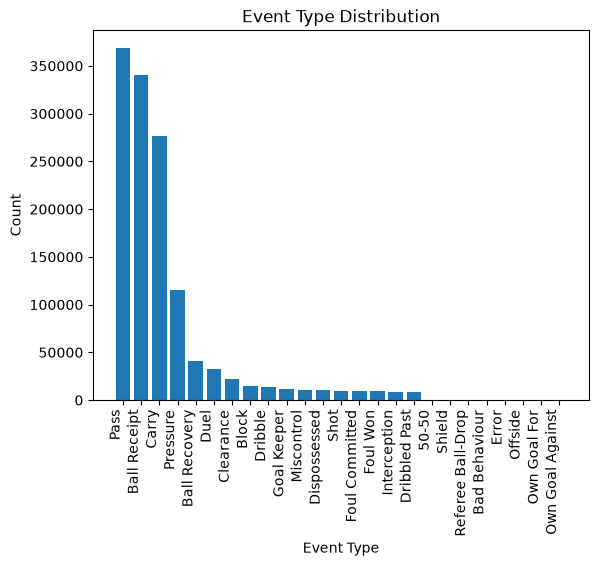

In [13]:
import matplotlib.pyplot as plt
# plot event type distribution
type_counts = playing_events_df.group_by('type').len().sort('len', descending=True)
type_counts = type_counts.with_columns(
    pl.col('type').replace_strict(event_types_dict, default=None).alias('name')
)
plt.bar(type_counts['name'].to_list(), type_counts['len'].to_list())
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.xticks(rotation=90, ha='right')
plt.ylabel("Count")


In [14]:
# look at one match
playing_events_df_42 = playing_events_df.filter(pl.col('match_id') == 42)

In [15]:
attack_events_ids = [14, 16, 30, 43] # dribble / shot / pass / carry
defend_events_ids = [2, 6, 9, 10, 17, 22] # ball recovery / block / clearance / interception / press / foul committed
combat_events_ids = [4, 28, 33] # duel / shield / 50/50
errors_events_ids = [3, 8, 37, 38, 39] # dispossessed / offside / error / miscontrol / dribbled past
ball_receipts_ids = [42]

In [16]:
# split the pitch into zones and assign each event to a zone based on its location
num_x_zones = 20
num_y_zones = 8

x_bins = np.linspace(0, 120, num_x_zones + 1)[:-1]
y_bins = np.linspace(0, 80, num_y_zones + 1)[:-1]

xy_bins = np.array(np.meshgrid(x_bins, y_bins)).T.reshape(-1, 2)
attack_xy_bins_dict = {(x, y): {z: 0 for z in attack_events_ids} for x, y in xy_bins}
defend_xy_bins_dict = {(x, y): {z: 0 for z in defend_events_ids} for x, y in xy_bins}
combat_xy_bins_dict = {(x, y): {z: 0 for z in combat_events_ids} for x, y in xy_bins}
errors_xy_bins_dict = {(x, y): {z: 0 for z in errors_events_ids} for x, y in xy_bins}
ball_receipts_xy_bins_dict = {(x, y): {42: 0} for x, y in xy_bins}

In [17]:
def fit_to_zone(x, y):
    if x is None or y is None:
        return None
    return (int(np.digitize(x, x_bins) - 1), int(np.digitize(y, y_bins) - 1))

playing_events_df = playing_events_df.with_columns(
    pl.struct(["location_x", "location_y"]).map_elements(
        lambda s: list(fit_to_zone(s["location_x"], s["location_y"])) if fit_to_zone(s["location_x"], s["location_y"]) is not None else None,
        return_dtype=pl.List(pl.Int64),
    ).alias("zone")
).with_columns(
    pl.col("zone").list.get(0).alias("x_zone"),
    pl.col("zone").list.get(1).alias("y_zone"),
).drop("zone")

playing_events_df = playing_events_df.with_columns(
    pl.struct(["end_location_x", "end_location_y"]).map_elements(
        lambda s: list(fit_to_zone(s["end_location_x"], s["end_location_y"])) if fit_to_zone(s["end_location_x"], s["end_location_y"]) is not None else None,
        return_dtype=pl.List(pl.Int64),
    ).alias("end_zone")
).with_columns(
    pl.col("end_zone").list.get(0).alias("x_end_zone"),
    pl.col("end_zone").list.get(1).alias("y_end_zone"),
).drop("end_zone")

In [18]:
# fill bin dictionaries with counts of events in each zone
for x in range(num_x_zones):
    x_id = x_bins[x]
    for y in range(num_y_zones):
        y_id = y_bins[y]
        zone_df = playing_events_df.filter(
            (pl.col("x_zone") == x) & (pl.col("y_zone") == y)
        )
        for event_id in attack_events_ids:
            attack_xy_bins_dict[(x_id, y_id)][event_id] = zone_df.filter(pl.col("type") == event_id).height
        for event_id in defend_events_ids:
            defend_xy_bins_dict[(x_id, y_id)][event_id] = zone_df.filter(pl.col("type") == event_id).height
        for event_id in combat_events_ids:
            combat_xy_bins_dict[(x_id, y_id)][event_id] = zone_df.filter(pl.col("type") == event_id).height
        for event_id in errors_events_ids:
            errors_xy_bins_dict[(x_id, y_id)][event_id] = zone_df.filter(pl.col("type") == event_id).height
        for event_id in ball_receipts_ids:
            ball_receipts_xy_bins_dict[(x_id, y_id)][event_id] = zone_df.filter(pl.col("type") == event_id).height

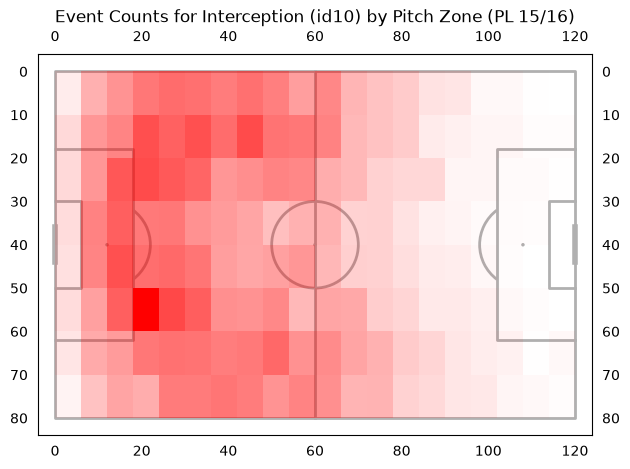

In [19]:
# plot pitch zones with event counts for attack events
from mplsoccer import Pitch
from matplotlib import pyplot as plt

def plot_event_counts(event_dict, event_id, title=None):
    pitch = Pitch(pitch_type='statsbomb', axis=True, label=True)
    fig, ax = pitch.draw()
    specific_id = event_id # e.g. dribble

    shapes = []
    counts = []
    # plot blocks on pitch from dict counts
    for x in range(num_x_zones):
        x_id = x_bins[x]
        for y in range(num_y_zones):
            y_id = y_bins[y]
            # generate shape for each zone based on its x and y coordinates
            shapes.append(np.array([[x_id, y_id], [x_id + 120/num_x_zones, y_id], [x_id + 120/num_x_zones, y_id + 80/num_y_zones], [x_id, y_id + 80/num_y_zones]]))
            count = event_dict[(x_id, y_id)][specific_id]
            counts.append(count)

    max_count = max(counts)

    for i, shape in enumerate(shapes):
        count = counts[i]
        if count > 0:
            pitch.polygon([shape], color='red', alpha=count / max_count, ax=ax, ec='none', lw=1)

    if title:
        plt.title(title)
    else:
        plt.title(f"Event Counts for {event_types_dict[specific_id]} (id{specific_id}) by Pitch Zone (PL 15/16)")

def plot_specific_event_counts(event_dict, event_name=None, team_name=None, title=None):
    # plot_event_counts where you don't need an event_id
    pitch = Pitch(pitch_type='statsbomb', axis=True, label=True)
    fig, ax = pitch.draw()

    shapes = []
    counts = []

    # plot blocks on pitch from dict counts
    for x in range(num_x_zones):
        x_id = x_bins[x]
        for y in range(num_y_zones):
            y_id = y_bins[y]
            # generate shape for each zone based on its x and y coordinates
            shapes.append(np.array([[x_id, y_id], [x_id + 120/num_x_zones, y_id], [x_id + 120/num_x_zones, y_id + 80/num_y_zones], [x_id, y_id + 80/num_y_zones]]))
            count = event_dict[(x_id, y_id)]
            counts.append(count)

    max_count = max(counts)

    for i, shape in enumerate(shapes):
        count = counts[i]
        if count > 0:
            pitch.polygon([shape], color='red', alpha=count / max_count, ax=ax, ec='none', lw=1)

    if title:
        plt.title(title)
    else:
        plt.title(f"{event_name} Counts by Pitch Zone for {team_name}(PL 15/16)")


plot_event_counts(defend_xy_bins_dict, 10) # interception

In [20]:
# save images for every event type in each category
import os
stem = f"outputs/premier_league_15_16"
os.makedirs(stem, exist_ok=True)

"""for event_id in attack_events_ids:
    plot_event_counts(attack_xy_bins_dict, event_id)
    plt.gca()
    plt.savefig(f"{stem}/attack_event_{event_id}_{event_types_dict[event_id]}.png")
    plt.close()

for event_id in defend_events_ids:
    plot_event_counts(defend_xy_bins_dict, event_id)
    plt.savefig(f"{stem}/defend_event_{event_id}_{event_types_dict[event_id]}.png")
    plt.close()

for event_id in combat_events_ids:
    plot_event_counts(combat_xy_bins_dict, event_id)
    plt.savefig(f"{stem}/combat_event_{event_id}_{event_types_dict[event_id]}.png")
    plt.close()

for event_id in errors_events_ids:
    plot_event_counts(errors_xy_bins_dict, event_id)
    plt.savefig(f"{stem}/errors_event_{event_id}_{event_types_dict[event_id]}.png")
    plt.close()

for event_id in ball_receipts_ids:
    plot_event_counts(ball_receipts_xy_bins_dict, event_id)
    plt.savefig(f"{stem}/ball_event_42_Receipt.png")
    plt.close()"""

'for event_id in attack_events_ids:\n    plot_event_counts(attack_xy_bins_dict, event_id)\n    plt.gca()\n    plt.savefig(f"{stem}/attack_event_{event_id}_{event_types_dict[event_id]}.png")\n    plt.close()\n\nfor event_id in defend_events_ids:\n    plot_event_counts(defend_xy_bins_dict, event_id)\n    plt.savefig(f"{stem}/defend_event_{event_id}_{event_types_dict[event_id]}.png")\n    plt.close()\n\nfor event_id in combat_events_ids:\n    plot_event_counts(combat_xy_bins_dict, event_id)\n    plt.savefig(f"{stem}/combat_event_{event_id}_{event_types_dict[event_id]}.png")\n    plt.close()\n\nfor event_id in errors_events_ids:\n    plot_event_counts(errors_xy_bins_dict, event_id)\n    plt.savefig(f"{stem}/errors_event_{event_id}_{event_types_dict[event_id]}.png")\n    plt.close()\n\nfor event_id in ball_receipts_ids:\n    plot_event_counts(ball_receipts_xy_bins_dict, event_id)\n    plt.savefig(f"{stem}/ball_event_42_Receipt.png")\n    plt.close()'

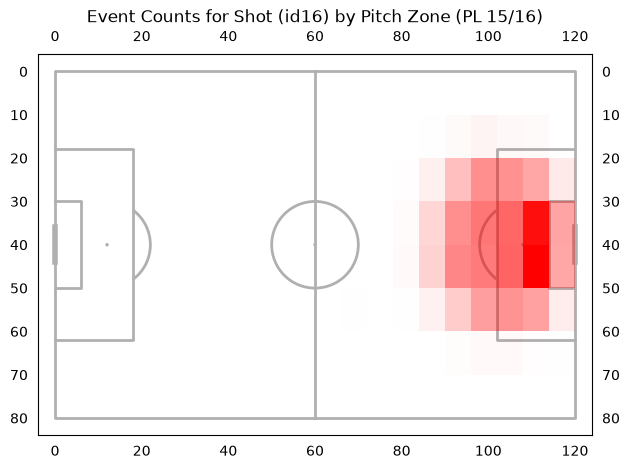

In [21]:
# plot shots
plot_event_counts(attack_xy_bins_dict, 16) # shot

In [22]:
# id 39 = Manchester United
# look at all shot events for Manchester United
man_utd_df = playing_events_df.filter(
    (pl.col('team') == 39)
)

man_utd_attack_xy_bins_dict = {(x, y): {z: 0 for z in attack_events_ids} for x, y in xy_bins}
for x in range(num_x_zones):
    x_id = x_bins[x]
    for y in range(num_y_zones):
        y_id = y_bins[y]
        zone_df = man_utd_df.filter(
            (pl.col("x_zone") == x) & (pl.col("y_zone") == y)
        )
        for event_id in attack_events_ids:
            man_utd_attack_xy_bins_dict[(x_id, y_id)][event_id] = zone_df.filter(pl.col("type") == event_id).height


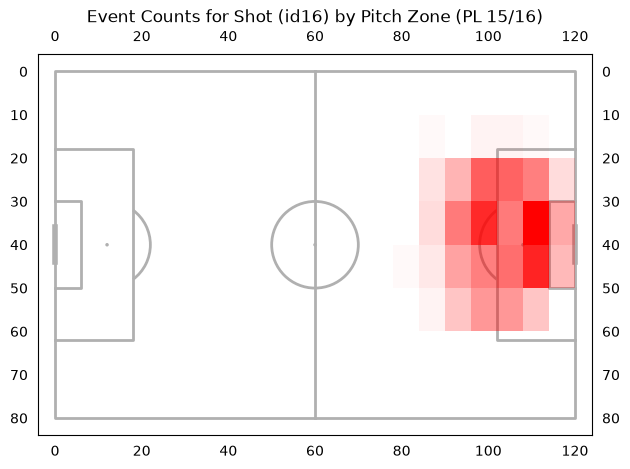

In [23]:
# plot Manchester United shot events
plot_event_counts(man_utd_attack_xy_bins_dict, 16) # shot

In [24]:
# get assists for Manchester United
man_utd_shots_df = man_utd_df.filter(pl.col('type') == 16) # shot
man_utd_goals_df = man_utd_shots_df.filter(pl.col('outcome') == 97) # goals scored not including own goals
man_utd_assists_df = man_utd_df.filter(pl.col('pass_goal_assist') == True) # assist
pl_assists_df = playing_events_df.filter(pl.col('pass_goal_assist') == True) # assist
pl_open_play_assists_df = pl_assists_df.filter(pl.col('play_pattern') != 2 ) # open play assist

In [25]:
man_utd_assists_dict = {(x, y): {42: 0} for x, y in xy_bins}
for x in range(num_x_zones):
    x_id = x_bins[x]
    for y in range(num_y_zones):
        y_id = y_bins[y]
        zone_df = man_utd_assists_df.filter(
            (pl.col("x_zone") == x) & (pl.col("y_zone") == y)
        )
        man_utd_assists_dict[(x_id, y_id)][42] = zone_df.height

pl_assists_dict = {(x, y): {42: 0} for x, y in xy_bins}
for x in range(num_x_zones):
    x_id = x_bins[x]
    for y in range(num_y_zones):
        y_id = y_bins[y]
        zone_df = pl_assists_df.filter(
            (pl.col("x_zone") == x) & (pl.col("y_zone") == y)
        )
        pl_assists_dict[(x_id, y_id)][42] = zone_df.height

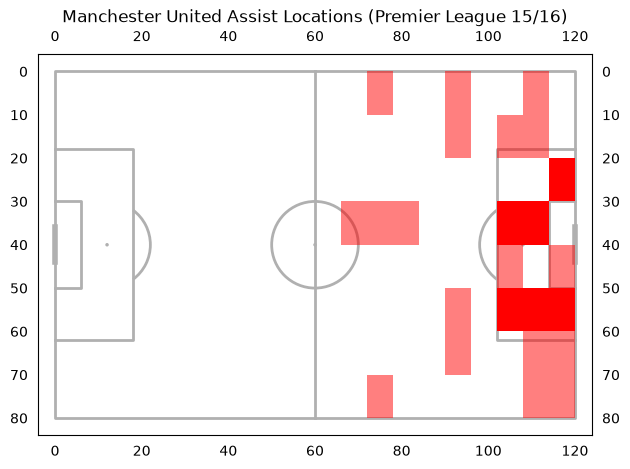

In [26]:
# plot assists for Manchester United
plot_event_counts(man_utd_assists_dict, 42, title="Manchester United Assist Locations (Premier League 15/16)") 

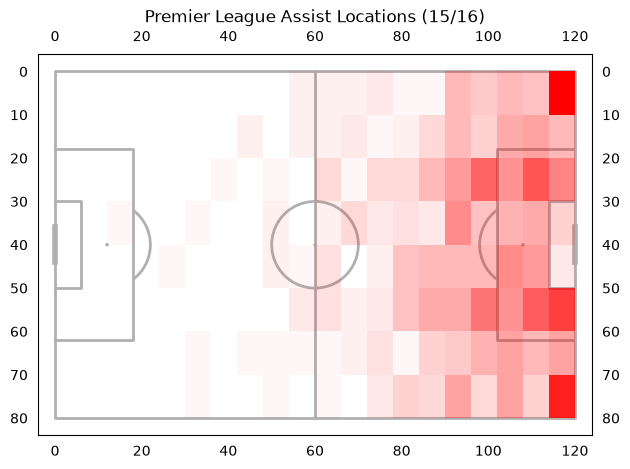

In [27]:
plot_event_counts(pl_assists_dict, 42, title="Premier League Assist Locations (15/16)")

In [28]:
# percentage of shots in each zone
shots_df = playing_events_df.filter(pl.col('type') == 16) # shot
shots_location_by_team_dict = {team_id: {} for team_id in teams_dict.keys()}
for team_id in teams_dict.keys():
    team_shots_df = shots_df.filter(pl.col('team') == team_id)
    for x in range(num_x_zones):
        x_id = x_bins[x]
        for y in range(num_y_zones):
            y_id = y_bins[y]
            zone_df = team_shots_df.filter(
                (pl.col("x_zone") == x) & (pl.col("y_zone") == y)
            )
            shots_location_by_team_dict[team_id][(x_id, y_id)] = zone_df.height

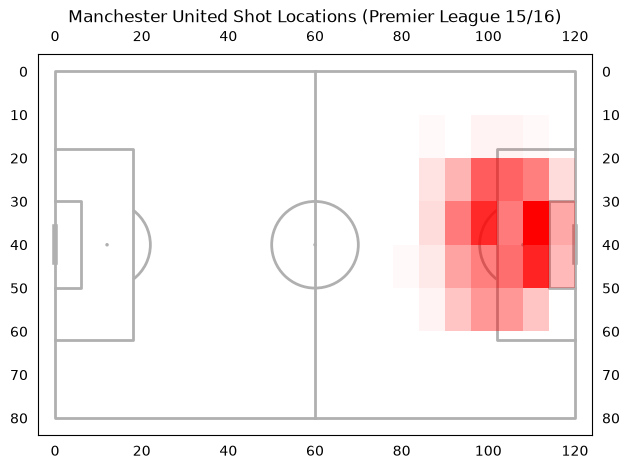

In [29]:
plot_specific_event_counts(shots_location_by_team_dict[39], event_name="Shots", team_name="Manchester United", title="Manchester United Shot Locations (Premier League 15/16)")

In [30]:
# playing_events_df: replace all empty values for outcome, where event is a pass, with 8
playing_events_df = playing_events_df.with_columns(
    pl.when((pl.col("type") == 30) & pl.col("outcome").is_null())
    .then(pl.lit(8))
    .otherwise(pl.col("outcome"))
    .alias("outcome")
)

In [31]:
# pass end locations to zones
completed_passes_df = playing_events_df.filter((pl.col('type') == 30) & (pl.col('outcome') == 8)) # pass
passes_end_location_by_team_dict = {team_id: {} for team_id in teams_dict.keys()}
for team_id in teams_dict.keys():
    team_passes_df = completed_passes_df.filter(pl.col('team') == team_id)
    for x in range(num_x_zones):
        x_id = x_bins[x]
        for y in range(num_y_zones):
            y_id = y_bins[y]
            zone_df = team_passes_df.filter(
                (pl.col("x_end_zone") == x) & (pl.col("y_end_zone") == y)
            )
            passes_end_location_by_team_dict[team_id][(x_id, y_id)] = zone_df.height

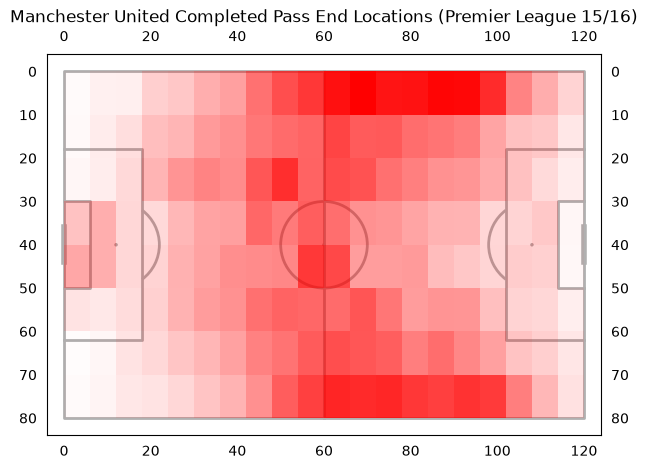

In [32]:
plot_specific_event_counts(passes_end_location_by_team_dict[39], event_name="Completed Passes End Location", team_name="Manchester United", title="Manchester United Completed Pass End Locations (Premier League 15/16)")

In [33]:
# expected threat model
# calculate probability of pass completion to a location given the ball is in a certain zone and the team is in possession of the ball
def pass_probability_matrix(playing_events_df):
    # filter for passes
    passes_df = playing_events_df.filter(pl.col('type') == 30)

    # group by x_zone, y_zone, x_end_zone, y_end_zone and count total passes and completed passes
    pass_counts_zone_to_zone_df = (
        passes_df
        .group_by(['x_zone', 'y_zone', 'x_end_zone', 'y_end_zone'])
        .agg([
            pl.col('type').count().alias('total_passes'),
            (pl.when(pl.col('outcome') == 8).then(1).otherwise(0)).sum().alias('completed_passes'),
        ])
    )

    # calculate probability of pass completion (guard against divide-by-zero)
    pass_counts_zone_to_zone_prob_df = pass_counts_zone_to_zone_df.with_columns(
        pl.when(pl.col('total_passes') > 0)
          .then(pl.col('completed_passes') / pl.col('total_passes'))
          .otherwise(None)
          .cast(pl.Float64)
          .alias('pass_completion_probability')
    )

    return pass_counts_zone_to_zone_df, pass_counts_zone_to_zone_prob_df

def plot_pass_probability_matrix(pass_counts_zone_to_zone_prob_df, team_id=None, title=None):
    pitch = Pitch(pitch_type='statsbomb', axis=True, label=True)
    fig, ax = pitch.draw()

    # collapse destination zones so each source zone is drawn once
    zone_prob_df = pass_counts_zone_to_zone_prob_df.group_by(['x_zone', 'y_zone']).agg(
        pl.col('pass_completion_probability').mean()
    )

    max_prob = zone_prob_df['pass_completion_probability'].max()

    for row in zone_prob_df.iter_rows(named=True):
        x = int(row['x_zone'])
        y = int(row['y_zone'])
        prob = row['pass_completion_probability']
        if prob is not None and max_prob not in (None, 0):
            x_id = x_bins[x]
            y_id = y_bins[y]
            shape = np.array([[x_id, y_id], [x_id + 120/num_x_zones, y_id], [x_id + 120/num_x_zones, y_id + 80/num_y_zones], [x_id, y_id + 80/num_y_zones]])
            pitch.polygon([shape], color='red', alpha=(prob / max_prob)**4, ax=ax, ec='none', lw=1)
            

    if title:
        plt.title(title)
    else:
        plt.title(f"Pass Completion Probability Matrix for Team {team_id} (PL 15/16)")


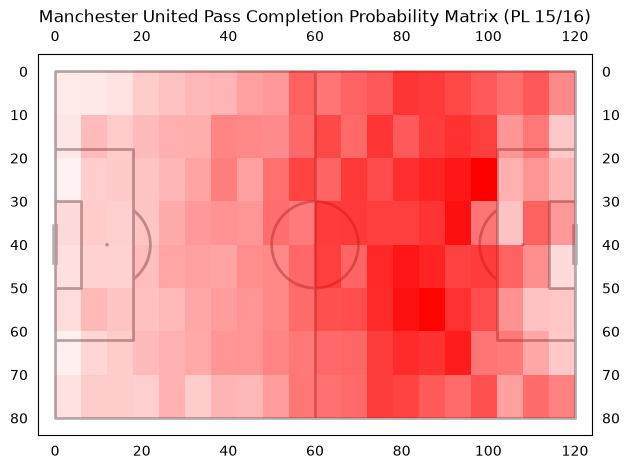

In [34]:
pass_prob_matrix, pass_prob_matrix_prob = pass_probability_matrix(playing_events_df)
z = plot_pass_probability_matrix(pass_prob_matrix_prob, team_id=39, title="Manchester United Pass Completion Probability Matrix (PL 15/16)")

In [35]:
pass_probability_matrix.__sizeof__()


136

In [36]:
index_event = lambda record: str(record['match_id']) + '_' + str(record['index'])
reverse_index_event = lambda index: {'match_id': int(index.split('_')[0]), 'index': int(index.split('_')[1])}
next_events = lambda df, match_id, index, max_lookahead: df.filter(
        (pl.col('match_id') == match_id) &
        (pl.col('index').is_between(index+1, index+max_lookahead)) &
        (pl.col('period') == df.filter((pl.col('match_id') == match_id) & 
                                    (pl.col('index') == index)
                                    ).select('period').item())
    )

In [41]:
def event_lookahead(df, lookahead=5):
    sorted_df = df.sort(['match_id', 'period', 'index'])

    next_type_cols = [
        pl.col('type').shift(-step).over(['match_id', 'period']).alias(f'next_type_{step}')
        for step in range(1, lookahead + 1)
    ]

    return (
        sorted_df
        .with_columns(next_type_cols)
        .filter(pl.col('type').is_in([30, 43]))
        .with_columns(
            pl.concat_list([pl.col(f'next_type_{step}') for step in range(1, lookahead + 1)])
            .alias(f'next_types_{lookahead}')
        )
        .drop([f'next_type_{step}' for step in range(1, lookahead + 1)])
    )


# outcomes mapping
# after the ball enters a zone, how likely is it that the team will a shot in the next 5 actions?
def calculate_outcome_probabilities(playing_events_df, outcome_type='shot', lookahead=5):
    # filter for events that are passes or carries
    # look at next five events by id
    # do not take the event if the period changes, as this indicates a stoppage in play
    # store only the types, later window of events will be used to calculate probability of outcome
    lookahead_df = event_lookahead(playing_events_df, lookahead)

    # define the outcome event type id
    outcome_event_id = 16 if outcome_type == 'shot' else None  # extend for other outcomes as needed

    # calculate the probability of the outcome occurring in the next 'lookahead' events
    # look at types of the next events from the dict and check if any of them match the outcome event type
    # so get lists in next_types_{lookahead} and check if any of them match the outcome_event_id

    outcome_lookahead_df = lookahead_df.with_columns(
        pl.col(f'next_types_{lookahead}')
        .list.contains(outcome_event_id)
        .cast(pl.Int64)
        .alias('outcome_occurred')
    )

    # group by current zone and calculate probabilities
    outcome_probabilities_df = (
        outcome_lookahead_df
        .group_by(['x_zone', 'y_zone'])
        .agg([
            pl.col('outcome_occurred').sum().alias('outcome_count'),
            pl.count().alias('total_count')
        ])
        .with_columns(
            (pl.col('outcome_count') / pl.col('total_count')).alias('outcome_probability')
        )
    )

    return outcome_probabilities_df

In [42]:
probs = calculate_outcome_probabilities(playing_events_df, outcome_type='shot', lookahead=5)

/var/folders/h_/lg0zhls57_l_8r2q6kbmsszw0000gn/T/ipykernel_57075/2848642381.py:50: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total_count')


In [43]:
# clustering of open-play passes
probs

x_zone,y_zone,outcome_count,total_count,outcome_probability
i64,i64,i64,u32,f64
10,4,68,8251,0.008241
15,6,308,4187,0.073561
14,1,243,4623,0.052563
1,4,38,8215,0.004626
6,5,14,5310,0.002637
…,…,…,…,…
16,1,327,3204,0.10206
10,6,48,6435,0.007459
18,4,200,472,0.423729
